<a href="https://colab.research.google.com/github/VarunSinha07/Bio-Verse/blob/main/Customer_Transaction_Analysis_Using_Matplotlib_and_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)

n = 20000

# Generate customer IDs
customer_ids = np.random.randint(1000, 5000, n)

# Generate ages
ages = np.random.normal(35, 12, n).astype(int)
ages = np.clip(ages, 18, 70)

# Generate annual income
income = np.random.normal(70000, 25000, n)
income = np.clip(income, 20000, 200000)

# Generate transaction amounts
purchase_amount = (
    income * np.random.uniform(0.001, 0.015, n)
    + np.random.normal(50, 30, n)
)
purchase_amount = np.round(np.clip(purchase_amount, 5, 3000), 2)

# Add some outliers
outlier_idx = np.random.choice(n, 100)
purchase_amount[outlier_idx] *= np.random.uniform(3, 10, 100)

# Generate transaction dates
start_date = datetime(2024, 1, 1)
dates = [
    start_date + timedelta(days=np.random.randint(0, 365))
    for _ in range(n)
]

# Categories
categories = np.random.choice(
    ['Electronics', 'Fashion', 'Groceries', 'Home', 'Sports'],
    n
)

# Number of items
items = np.random.randint(1, 10, n)

# Create dataframe
df = pd.DataFrame({
    'Transaction_ID': range(1, n + 1),
    'Customer_ID': customer_ids,
    'Age': ages,
    'Income': income.astype(int),
    'Purchase_Amount': purchase_amount,
    'Items_Purchased': items,
    'Category': categories,
    'Transaction_Date': dates
})

# Save CSV
df.to_csv('customer_transactions.csv', index=False)

print("Dataset created successfully!")
print(df.head())

print("\nContent of customer_transactions.csv file:")
df_from_csv = pd.read_csv('customer_transactions.csv')
print(df_from_csv.head())

Dataset created successfully!
   Transaction_ID  Customer_ID  Age  Income  Purchase_Amount  Items_Purchased  \
0               1         4174   26   59685           912.26                2   
1               2         4507   59   59626           665.41                6   
2               3         1860   23   98752           812.77                5   
3               4         2294   18   20000           141.28                8   
4               5         2130   35   89512           341.15                7   

      Category Transaction_Date  
0         Home       2024-04-14  
1  Electronics       2024-09-07  
2      Fashion       2024-02-14  
3       Sports       2024-07-08  
4  Electronics       2024-12-26  

Content of customer_transactions.csv file:
   Transaction_ID  Customer_ID  Age  Income  Purchase_Amount  Items_Purchased  \
0               1         4174   26   59685           912.26                2   
1               2         4507   59   59626           665.41             

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Better plot appearance
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [5]:
df = pd.read_csv("customer_transactions.csv")

In [6]:
df.head()

,Transaction_ID,Customer_ID,Age,Income,Purchase_Amount,Items_Purchased,Category,Transaction_Date
0,1,4174,26,59685,912.26,2,Home,2024-04-14
1,2,4507,59,59626,665.41,6,Electronics,2024-09-07
2,3,1860,23,98752,812.77,5,Fashion,2024-02-14
3,4,2294,18,20000,141.28,8,Sports,2024-07-08
4,5,2130,35,89512,341.15,7,Electronics,2024-12-26


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction_ID    20000 non-null  int64  
 1   Customer_ID       20000 non-null  int64  
 2   Age               20000 non-null  int64  
 3   Income            20000 non-null  int64  
 4   Purchase_Amount   20000 non-null  float64
 5   Items_Purchased   20000 non-null  int64  
 6   Category          20000 non-null  object 
 7   Transaction_Date  20000 non-null  object 
dtypes: float64(1), int64(5), object(2)
memory usage: 1.2+ MB


In [8]:
df.describe()

,Transaction_ID,Customer_ID,Age,Income,Purchase_Amount,Items_Purchased
count,20000.000000,20000.000000,20000.00000,20000.00000,20000.000000,20000.000000
mean,10000.500000,2997.250250,34.98665,70334.90945,626.515541,4.976800
std,5773.647028,1153.744482,11.09088,24547.53530,436.023190,2.572332
min,1.000000,1000.000000,18.00000,20000.00000,12.890000,1.000000
25%,5000.750000,1992.000000,26.00000,53375.75000,321.575000,3.000000
50%,10000.500000,2981.000000,35.00000,69997.00000,557.135000,5.000000
75%,15000.250000,3999.000000,43.00000,86854.50000,846.777500,7.000000
max,20000.000000,4999.000000,70.00000,172486.00000,10216.593401,9.000000


In [9]:
df.columns

Index(['Transaction_ID', 'Customer_ID', 'Age', 'Income', 'Purchase_Amount',
       'Items_Purchased', 'Category', 'Transaction_Date'],
      dtype='object')

In [10]:
df.isnull().sum()


,0
Transaction_ID,0
Customer_ID,0
Age,0
Income,0
Purchase_Amount,0
Items_Purchased,0
Category,0
Transaction_Date,0


In [11]:
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])

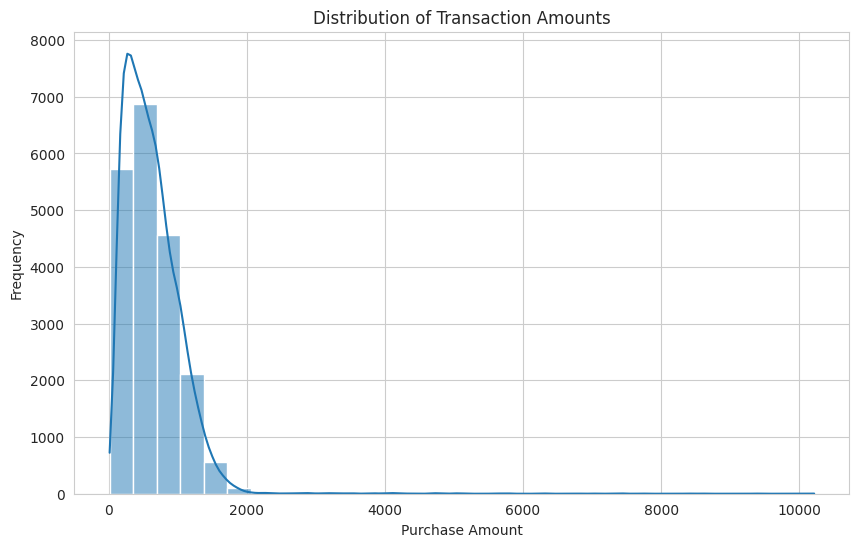

In [12]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Purchase_Amount'],
    bins=30,
    kde=True
)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")

plt.show()

In [13]:
corr_cols = [
    'Age',
    'Income',
    'Purchase_Amount',
    'Items_Purchased'
]

corr_matrix = df[corr_cols].corr()

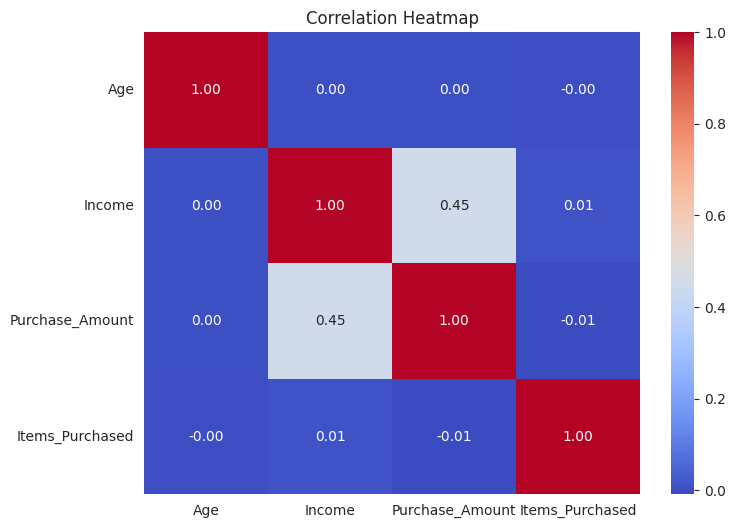

In [14]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

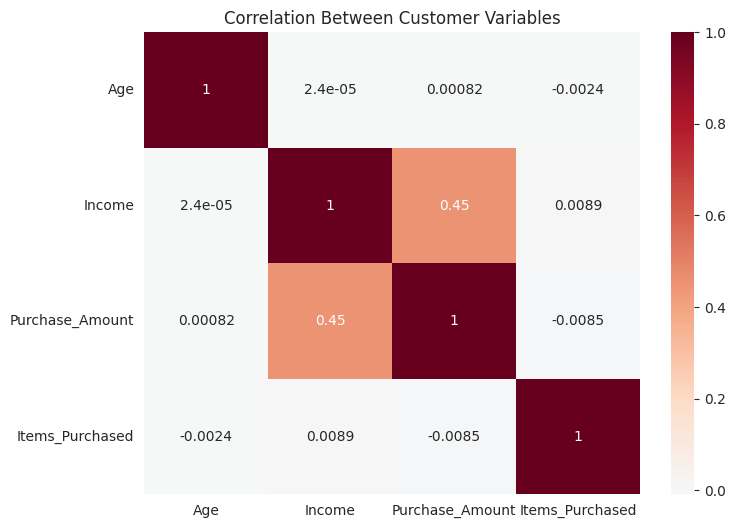

In [15]:
mask = corr_matrix.abs() < 0.1

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='RdBu_r',
    center=0
)

plt.title("Correlation Between Customer Variables")

plt.show()

In [16]:
daily_transactions = (
    df.groupby('Transaction_Date')
      .size()
      .reset_index(name='Transaction_Count')
)

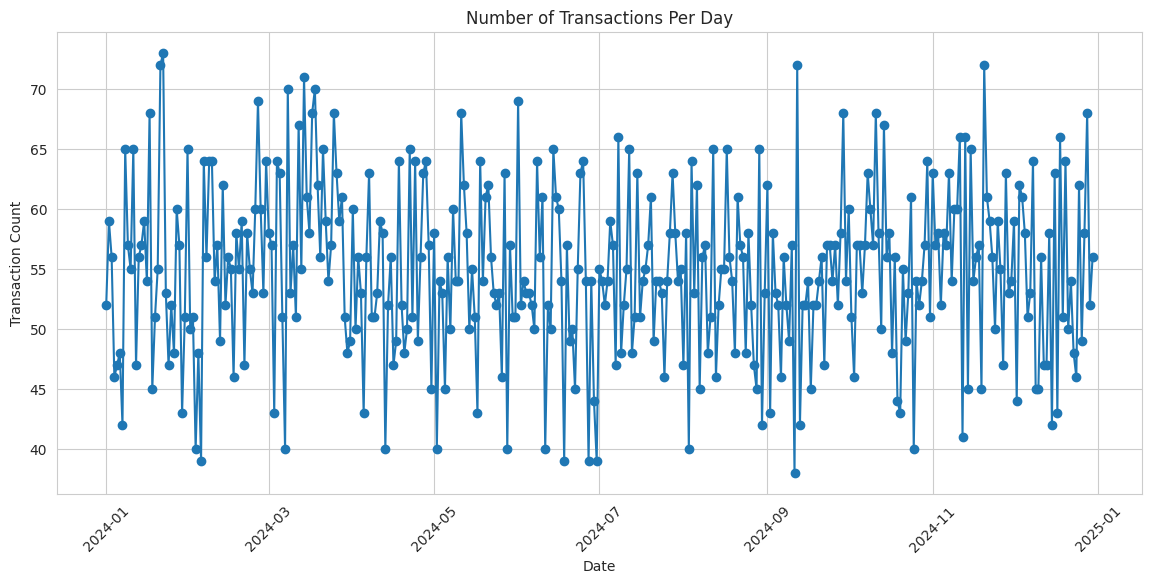

In [17]:
plt.figure(figsize=(14,6))

plt.plot(
    daily_transactions['Transaction_Date'],
    daily_transactions['Transaction_Count'],
    marker='o'
)

plt.title("Number of Transactions Per Day")
plt.xlabel("Date")
plt.ylabel("Transaction Count")

plt.xticks(rotation=45)

plt.show()

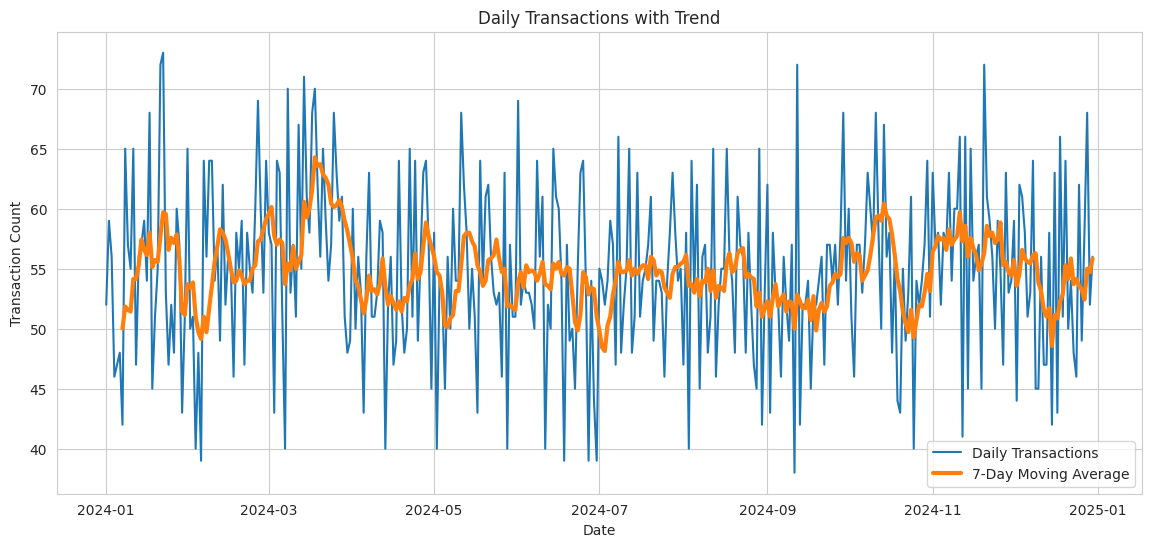

In [18]:
daily_transactions['Moving_Average'] = (
    daily_transactions['Transaction_Count']
    .rolling(7)
    .mean()
)

plt.figure(figsize=(14,6))

plt.plot(
    daily_transactions['Transaction_Date'],
    daily_transactions['Transaction_Count'],
    label='Daily Transactions'
)

plt.plot(
    daily_transactions['Transaction_Date'],
    daily_transactions['Moving_Average'],
    linewidth=3,
    label='7-Day Moving Average'
)

plt.title("Daily Transactions with Trend")

plt.xlabel("Date")
plt.ylabel("Transaction Count")

plt.legend()

plt.show()

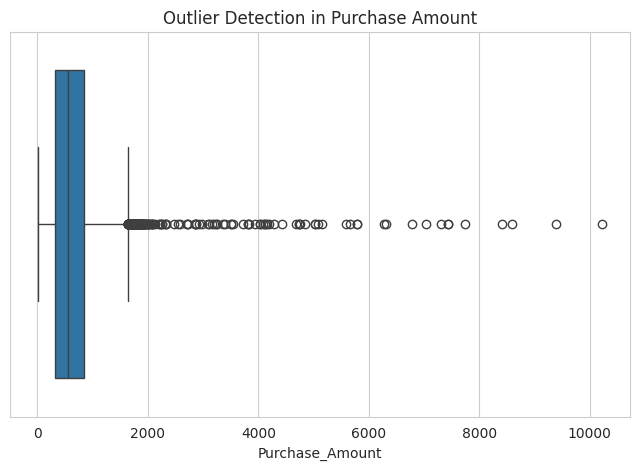

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['Purchase_Amount']
)

plt.title("Outlier Detection in Purchase Amount")

plt.show()

In [20]:
Q1 = df['Purchase_Amount'].quantile(0.25)
Q3 = df['Purchase_Amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Purchase_Amount'] < lower_bound) |
    (df['Purchase_Amount'] > upper_bound)
]

print("Number of Outliers:", len(outliers))
print(outliers.head())

Number of Outliers: 239
     Transaction_ID  Customer_ID  Age  Income  Purchase_Amount  \
50               51         3734   27  111617      1668.870000   
123             124         2076   46  116249      1756.990000   
134             135         4884   28   57637      2864.721834   
177             178         4810   23  127471      1725.480000   
301             302         3777   40  131587      1702.540000   

     Items_Purchased     Category Transaction_Date  
50                 4  Electronics       2024-03-22  
123                2      Fashion       2024-11-17  
134                6  Electronics       2024-07-10  
177                1       Sports       2024-10-22  
301                8      Fashion       2024-02-12  


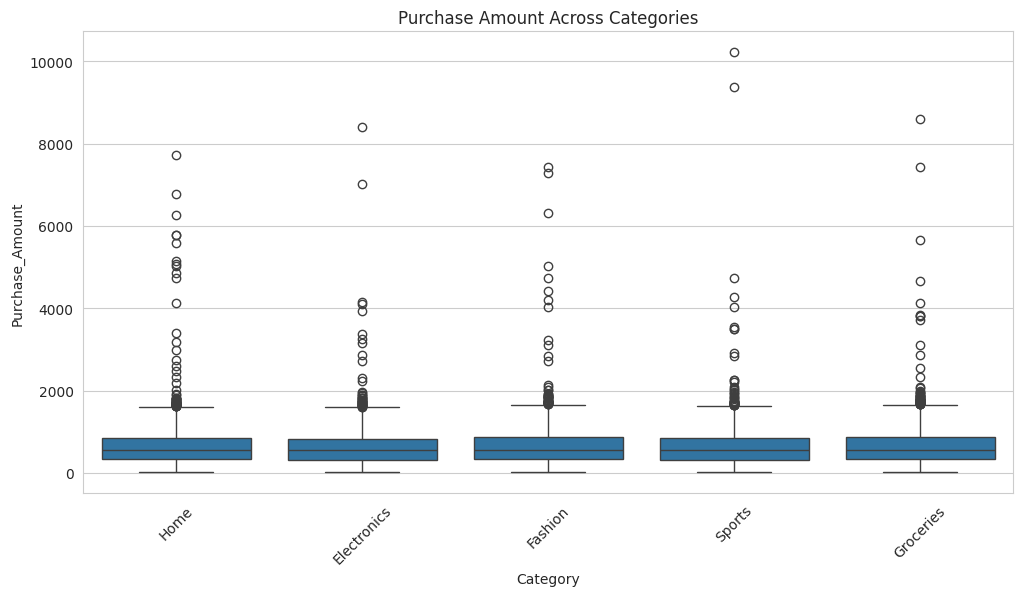

In [21]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='Category',
    y='Purchase_Amount',
    data=df
)

plt.title("Purchase Amount Across Categories")

plt.xticks(rotation=45)

plt.show()